# rsds latitude check

Markdown was generated by Claude, then reviewed and edited.

This notebook is a bug/artifact detector for debiased and downscaled `rsds` (surface downwelling shortwave radiation), not a measure of bias magnitude. It asks a narrow question: does the pipeline output ever exceed a value that we expect should be the max given the latitude and time of year? (i.e., it has never occurred at that latitude and time of year, in ERA5 observations or in any of the raw GCM inputs across scenarios?). While it is mathematically possible for BCSD to generate values that cross this ceiling, any such points should be carefully scrutinized.

The ceiling is built as a function of `(dayofyear, lat)`: the maximum `rsds` across all longitudes in that latitude band (a "zonal max"), taken across ERA5 and three GCMs (`CESM2-WACCM`, `UKESM`, `MIROC-ES2H`) and three scenario groups (`historical`, `g6_1p5k`, `ssp245`). Because it is the *union* of several models' and scenarios' extremes, further loosened by maxing over longitude, it is deliberately a high bar rather than a tight statistical bound. It only depends on the input data, not on which output is being checked, so it is cached rather than recomputed on every run.

This is an intentionally simpler, standalone check -- it is not connected to the rolling-window plausible-bounds check in `srm.qaqc.calculate_reasonable_bounds_doy`. The evaluation currently covers one debiased output (`CESM2-WACCM`, `ssp245`, ensemble member `003`) as a first pass.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr

from srm import catalog
from srm.downscaling_utils import interpolate_coarse_to_fine_grid
from srm.utils import open_icechunk

In [2]:
CACHE_PATH = "s3://carbonplan-scratch/srm/qaqc/zonal_doy_max_rsds.zarr"


def load_cached(key: str) -> xr.DataArray | None:
    """None on a cache miss; the caller decides what to do about it."""
    try:
        return xr.open_zarr(CACHE_PATH, group=key)["data"].load()
    except FileNotFoundError:
        return None


def save_cached(key: str, da: xr.DataArray) -> None:
    da.rename("data").to_dataset().to_zarr(CACHE_PATH, group=key, mode="w")

# Calculate max plausible solar radiation
This is of dimensions [lat,dayofyear] and we are calculating a really high max bound: the maximum downwelling solar radiation at the surface across all longitudes in that zonal band, in observations and across historical and future scenarios.

This only needs to be done once. (Only needs to be rerun if the input data changes)

Load ERA5 as the fine reference grid: it's both the observational input to the ceiling and the common fine grid every GCM below gets regridded onto, so all sources land on the same grid before combining.

In [ ]:
fine_obs = catalog.get("ERA5").to_xarray()["rsds"]

For one GCM's coarse-resolution time series: reduce to a day-of-year max, regrid that onto the fine ERA5 grid with `interpolate_coarse_to_fine_grid`, then take the max across longitude to get that source's zonal day-of-year bound.

In [ ]:
def calculate_fine_gcm_zonal_limit(coarse_gcm_grid_tseries, fine_obs_doy):
    coarse_gcm_doy_grid = coarse_gcm_grid_tseries.groupby("time.dayofyear").max(dim="time")
    fine_gcm_doy_grid = interpolate_coarse_to_fine_grid(
        da_coarse_to_regrid=coarse_gcm_doy_grid, da_fine_grid=fine_obs_doy
    )
    fine_gcm_doy_zonal = fine_gcm_doy_grid.max(dim="lon")

    return fine_gcm_doy_zonal

The same reduction applied directly to ERA5, which is already on the fine grid so no regridding step is needed.

In [ ]:
fine_obs_doy = fine_obs.groupby("time.dayofyear").max(dim="time")
fine_obs_doy_zonal = fine_obs_doy.max(dim="lon")

Generic cache helpers: write/read a DataArray to/from one zarr store, keyed by a string group name. Nothing here is specific to `rsds`.

Combine every source into one ceiling: for each GCM x scenario combination, compute that source's zonal day-of-year max with the helper above, and keep a running elementwise maximum across all of them, starting from the ERA5 value. `zonal_limit_across_all` is the final ceiling, committed to the cache in the next cell.

In [ ]:
zonal_limit_across_all = fine_obs_doy_zonal

plot_gcm_limits = False

for gcm in ["CESM2-WACCM", "UKESM", "MIROC-ES2H"]:
    print(gcm)
    for scenario in ["historical", "g6_1p5k", "ssp245"]:
        print(scenario)

        gcm_scenario = catalog.get(gcm).to_xarray()[scenario]["rsds"]

        gcm_zonal_limit = (
            calculate_fine_gcm_zonal_limit(gcm_scenario, fine_obs_doy=fine_obs_doy)
            .max(dim="ensemble_member")
            .load()
        )

        zonal_limit_across_all = zonal_limit_across_all.where(
            (zonal_limit_across_all > gcm_zonal_limit) | gcm_zonal_limit.isnull(), gcm_zonal_limit
        ).load()

        if plot_gcm_limits:
            plt.figure()
            gcm_zonal_limit.plot()
            plt.show()

In [ ]:
save_cached(key="zonal_doy_max_rsds", da=zonal_limit_across_all)

# Do evaluation

Load the cached ceiling (skip Part 1 above unless the input data changed) and sanity-check it: as a function of (dayofyear, lat) it should look like an insolation climatology -- peaking near each latitude's local summer solstice, near zero inside that hemisphere's winter polar night.

In [3]:
zonal_doy_max_rsds = load_cached(key="zonal_doy_max_rsds")

Text(0, 0.5, 'Mean surface downward short-wave radiation flux [W m-2]')

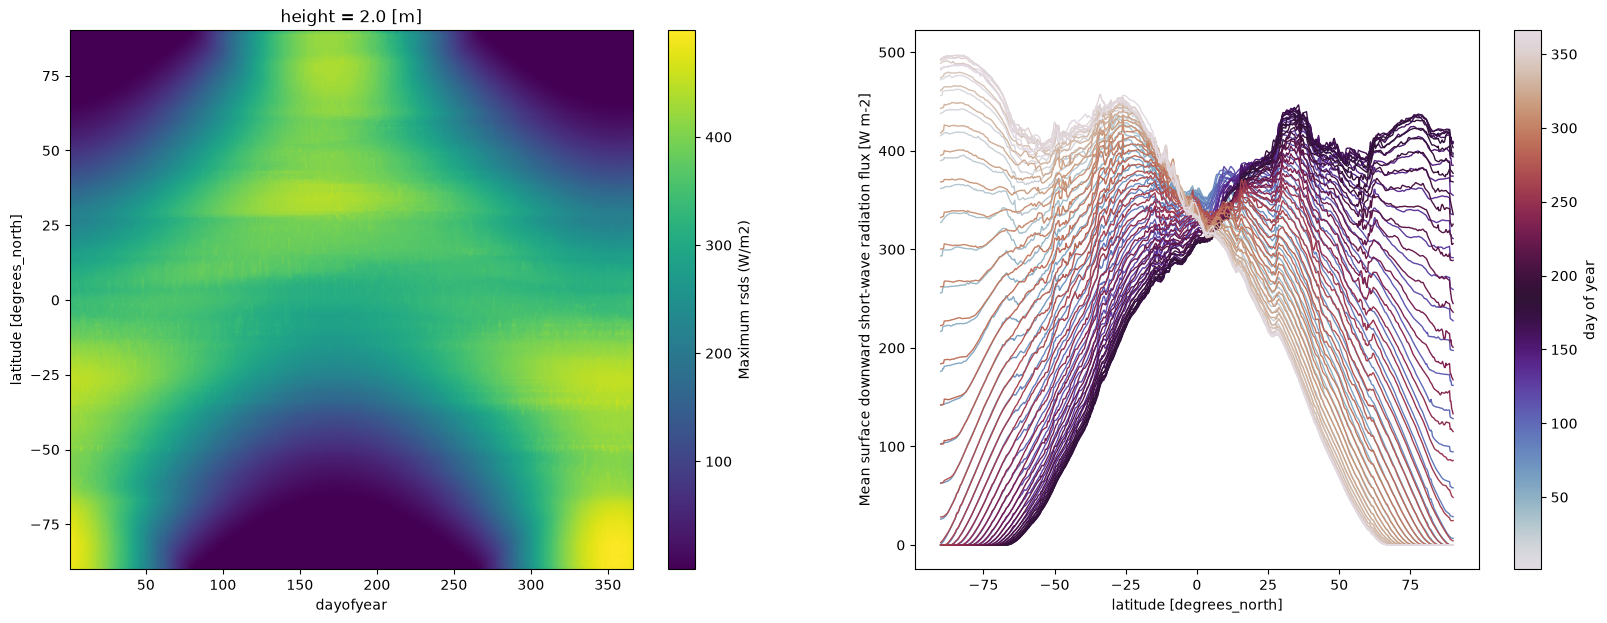

In [4]:
fig, axes = plt.subplots(figsize=(20, 7), ncols=2)

zonal_doy_max_rsds.transpose().plot(ax=axes[0], cbar_kwargs={"label": "Maximum rsds (W/m2)"})

ax = axes[1]
cmap = plt.get_cmap("twilight")  # cyclic: doy 1 and 366 are seasonally adjacent
norm = mpl.colors.Normalize(vmin=1, vmax=366)

for doy in zonal_doy_max_rsds["dayofyear"].values[::5]:
    zonal_doy_max_rsds.sel(dayofyear=doy).plot(
        ax=ax, color=cmap(norm(doy)), add_legend=False, linewidth=1
    )

fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="day of year")
ax.set_title("")
ax.set_xlabel("latitude [degrees_north]")
ax.set_ylabel("Mean surface downward short-wave radiation flux [W m-2]")

Pick one pipeline output to evaluate against the ceiling, and load both the fine (downscaled) debiased result and its coarse debiased counterpart (pre-downscaling) -- comparing the two against the ceiling later shows whether downscaling introduces or amplifies exceedances that weren't already present before it.

In [5]:
path_output = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/CESM2-WACCM-ERA5-global.icechunk"
branch = "v0.12.0"

In [6]:
var = "rsds"
scenario = "ssp245"
ens = "003"

In [7]:
ds_debiased = open_icechunk(
    path=path_output,
    branch=branch,
    group=scenario + "/" + var + "/" + ens,
)[var]

coarse_debiased = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/" + scenario + "/" + var + "/" + ens,
)[var]

Align the ceiling onto the output's (time, lat, lon) grid via the day-of-year lookup, then reduce to two summaries: `exceeds_max_freq`, the fraction of days each cell crosses it, and `delta_above_max`, the single largest overshoot at each cell (masked to where an exceedance actually happened).

In [8]:
aligned_max = zonal_doy_max_rsds.sel(dayofyear=ds_debiased.time.dt.dayofyear)
exceeds_max = ds_debiased > aligned_max
exceeds_max_freq = exceeds_max.mean(dim="time").load()
delta_above_max = (ds_debiased - aligned_max).max(dim="time")
delta_above_max = delta_above_max.where(delta_above_max > 0).load()

In [9]:
delta_above_max = delta_above_max.where(delta_above_max > 0).load()

Two maps:
* Map of how often each cell exceeds the ceiling (fraction of days), capped at 10% so the handful of true outliers don't wash out everywhere else.
* Map of the maximum amount each cell goes above the ceiling

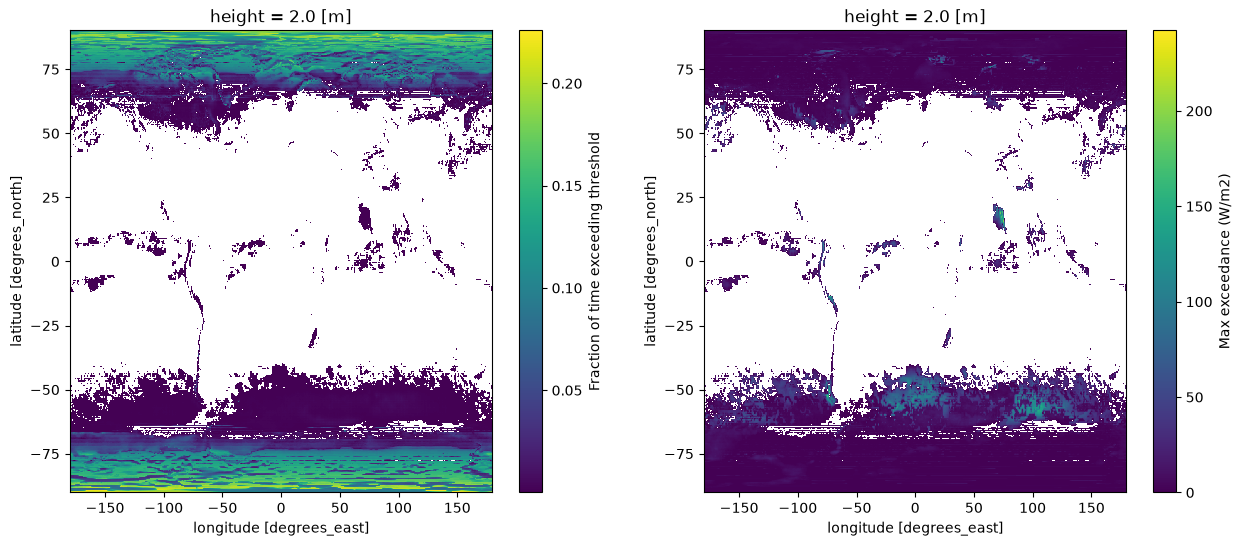

In [32]:
# from matplotlib.colors import LogNorm

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
exceeds_max_freq.where(exceeds_max_freq > 0).plot(
    cbar_kwargs={"label": "Fraction of time exceeding threshold"},  # vmax=0.1,
)
plt.subplot(1, 2, 2)
delta_above_max.plot(
    # norm=LogNorm(),
    cbar_kwargs={"label": "Max exceedance (W/m2)"},  # vmax=15,
)

Zoom into the region with the largest overshoot (lon 60-80, lat 10-25 -- South Asia) to pick a point to drill into below.

# Single point example

Drill into a single cell inside the zoomed region above (lat=17, lon=72.5) where the overshoot map showed some of the largest values, and look at the full daily distribution against the ceiling rather than just the worst day.

In [27]:
# Another outlier point
# pt_lat=15.75
# pt_lon=75.0

pt_lat = -15
pt_lon = -71

pt_ds_debiased = ds_debiased.sel(lat=pt_lat, lon=pt_lon, method="nearest")
pt_coarse_debiased = coarse_debiased.sel(lat=pt_lat, lon=pt_lon, method="nearest")
pt_zonal_doy_max_rsds = zonal_doy_max_rsds.sel(lat=pt_lat, method="nearest")

In [28]:
aligned_max_pt = pt_zonal_doy_max_rsds.sel(dayofyear=pt_ds_debiased.time.dt.dayofyear)

In [29]:
pt_exceeds_max = pt_ds_debiased > aligned_max_pt
pt_coarse_exceeds_max = pt_coarse_debiased > aligned_max_pt

Panels circle days where the downscaled debiased value (`pt_ds_debiased`) or coarse debiased value (`pt_coarse_debiased`) exceeded the ceiling. Left shows those days at the downscaled stage; right shows the days at the coarse debiased (pre-downscaling) stage.

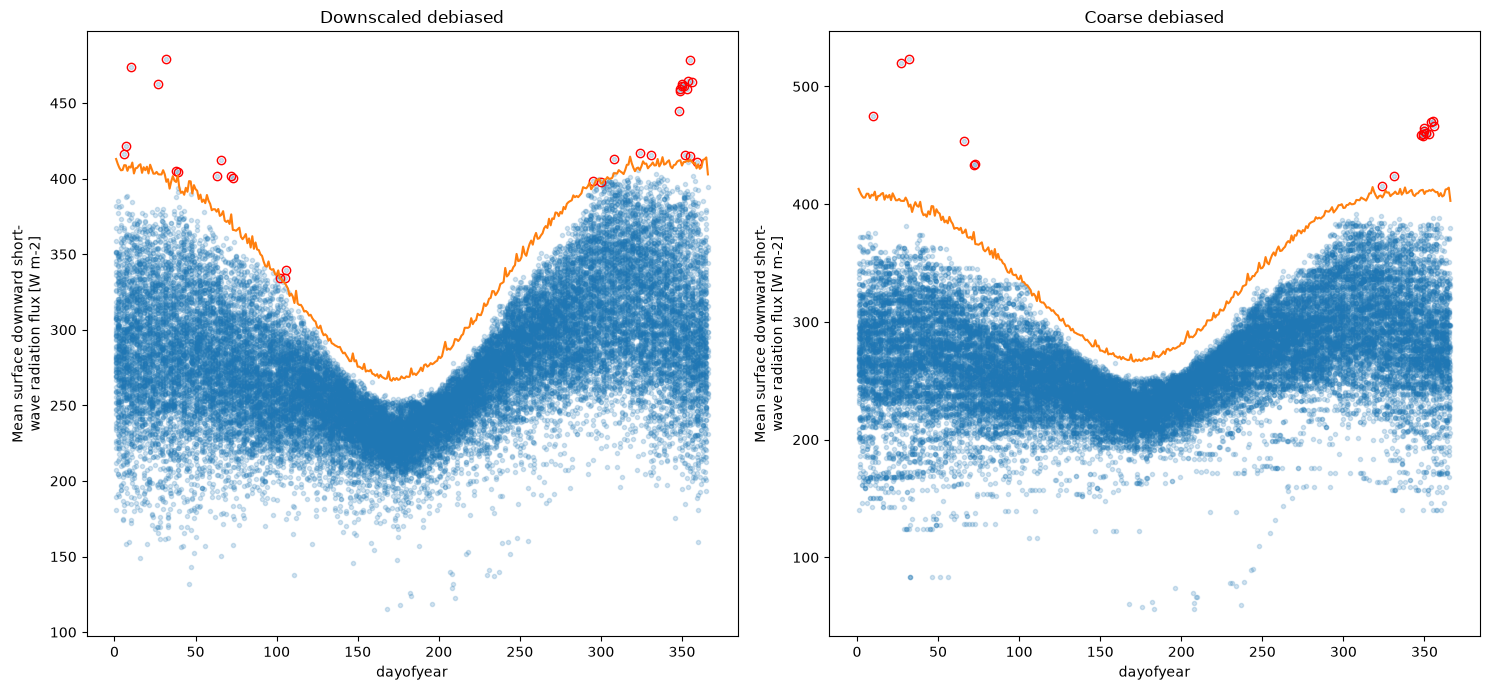

In [30]:
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.plot(pt_ds_debiased["time.dayofyear"], pt_ds_debiased, ".", alpha=0.2)
plt.plot(
    pt_ds_debiased["time.dayofyear"], pt_ds_debiased.where(pt_exceeds_max), "or", fillstyle="none"
)
pt_zonal_doy_max_rsds.plot()
plt.title("Downscaled debiased")

plt.subplot(1, 2, 2)
plt.plot(pt_coarse_debiased["time.dayofyear"], pt_coarse_debiased, ".", alpha=0.2)
plt.plot(
    pt_coarse_debiased["time.dayofyear"],
    pt_coarse_debiased.where(pt_coarse_exceeds_max),
    "or",
    fillstyle="none",
)
pt_zonal_doy_max_rsds.plot()
plt.title("Coarse debiased")

plt.tight_layout()